In [38]:
import sys
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/autoencoder/src')
from data_loader import *

sys.path.append('../..')
from python.animation import *
from python.postprocess import *
from python.polygon_based_correction import *
from eval import *

import sleap
sleap.versions()
sleap.system_summary()

from tqdm import tqdm

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
dataset = sleap.load_file(corrected_dataset_path)
tracked_points = get_all_tracked_points(dataset, reorder=True, interpolate=False, min_score=0, start_idx=0)

all_tracked_points shape: (9000, 17, 2)
First non missing frame idx: 0
Missing point count: 7440
reorder_idx.shape: (17,)


## determine window size

mean_radii: [23.82662064 25.56906133 23.13777215 23.42059619 23.63383226 25.65908751
 22.35174999 22.69927543 24.38469717 23.3873932  25.0726186  23.96431911
 22.5662053  22.09107162 25.15705849 22.90592326 20.55936431]
total_range_length: 5765
Stable ranges (frame numbers) with minimum length of 1 frames and all radii above 50.0% mean:
    - Frames 0 to 1612 (length: 1612)
    - Frames 1614 to 1728 (length: 114)
    - Frames 1730 to 1768 (length: 38)
    - Frames 1774 to 1779 (length: 5)
    - Frames 1783 to 1801 (length: 18)
    - Frames 1803 to 1843 (length: 40)
    - Frames 1850 to 1853 (length: 3)
    - Frames 1855 to 1871 (length: 16)
    - Frames 1873 to 1888 (length: 15)
    - Frames 1908 to 1991 (length: 83)
    - Frames 1993 to 2018 (length: 25)
    - Frames 2029 to 2032 (length: 3)
    - Frames 2034 to 2047 (length: 13)
    - Frames 2049 to 2064 (length: 15)
    - Frames 2066 to 2068 (length: 2)
    - Frames 2071 to 2076 (length: 5)
    - Frames 2091 to 2119 (length: 28)
   

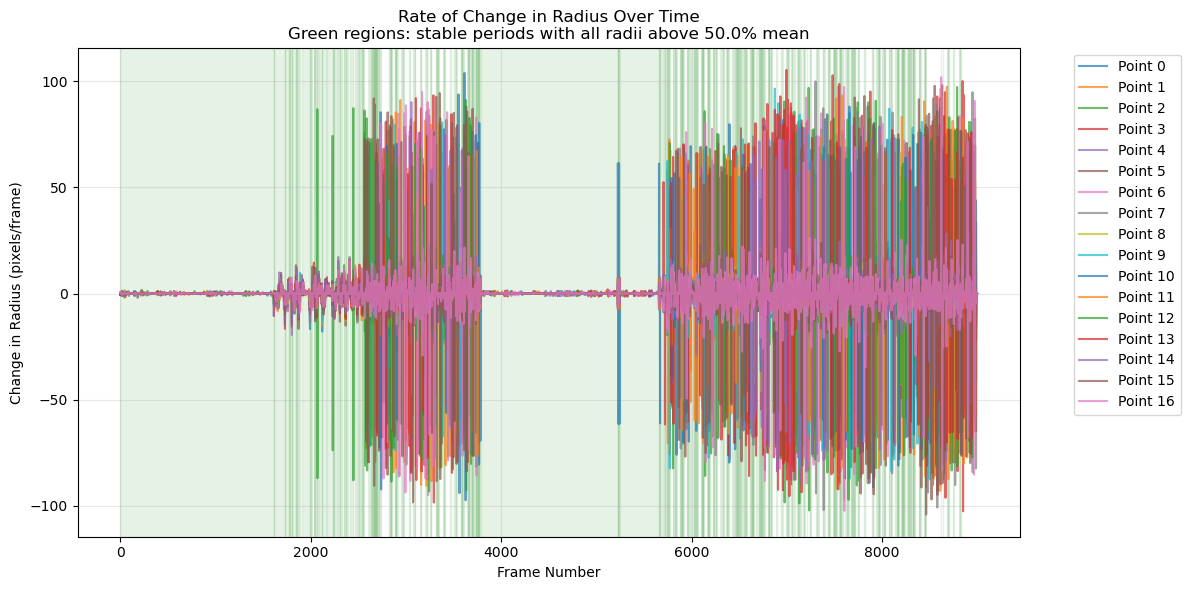

In [3]:
all_radii = get_all_radii(tracked_points)
filtered_ranges = get_expanded_periods(all_radii, 
                                        min_range_length=1, mean_scale=0.5, derivative_thres=10, 
                                        plot=True, verbose=True, use_mean=True)

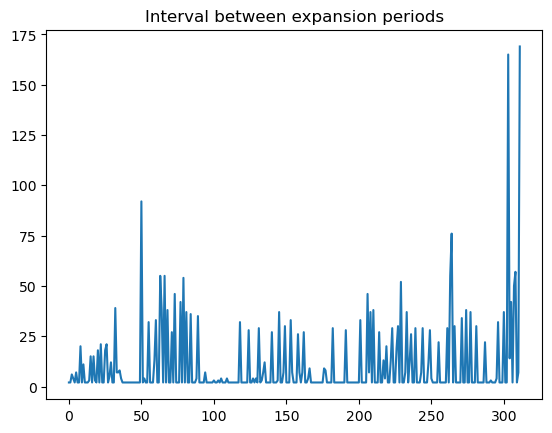

In [ ]:
interval_btwn_expansions = []
for frame_idx, (start_idx, end_idx) in enumerate(filtered_ranges):
    if frame_idx == 0:
        if start_idx != 0:
            interval_btwn_expansions.append(start_idx)
    else:
        interval_btwn_expansions.append(start_idx - filtered_ranges[frame_idx-1][1])
total_frame_cnt = len(tracked_points)
if total_frame_cnt > filtered_ranges[-1][1]:
    interval_btwn_expansions.append(total_frame_cnt - filtered_ranges[-1][1])

plt.title('Interval between expansion periods')
plt.plot(interval_btwn_expansions)
plt.show()

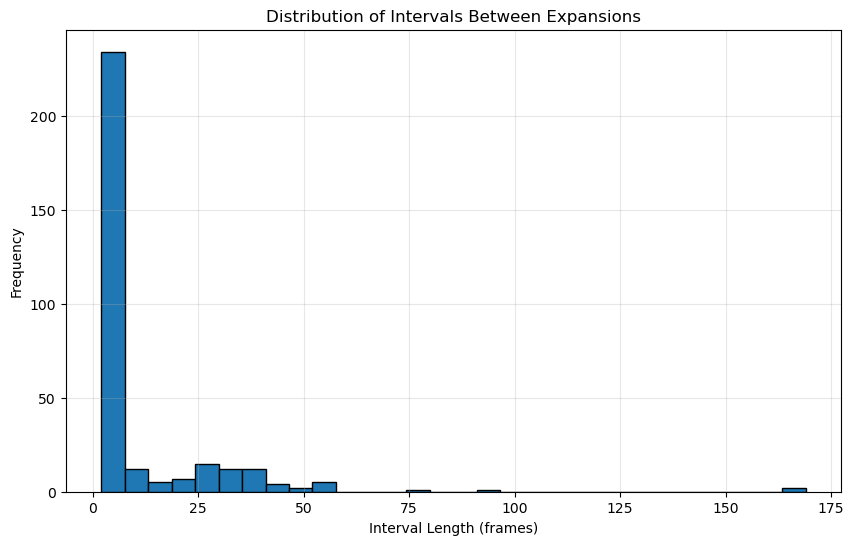

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(interval_btwn_expansions, bins=30, edgecolor='black')
plt.xlabel('Interval Length (frames)')
plt.ylabel('Frequency')
plt.title('Distribution of Intervals Between Expansions')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
np.percentile(interval_btwn_expansions, 90)

32.900000000000034

## generate time window stacks

In [16]:
window_size = 30
tracked_pts_windows = get_windows_wrapper([tracked_points], window_size=window_size, flatten=False)[0]

In [17]:
tracked_pts_windows.shape


(9000, 30, 17, 2)

## reorder by polygon per window

In [21]:
def generate_window_indices(frame_cnt, window_size):
    first_half_window = window_size // 2
    second_half_window = window_size - first_half_window
    window_indices = np.zeros((frame_cnt, window_size), dtype=np.int32)
    for i in range(frame_cnt):
        window_indices[i] = np.arange(i - first_half_window, i + second_half_window)
    window_indices = np.clip(window_indices, 0, frame_cnt - 1)
    return window_indices

In [22]:
window_indices = generate_window_indices(10, 5)
window_indices

array([[0, 0, 0, 1, 2],
       [0, 0, 1, 2, 3],
       [0, 1, 2, 3, 4],
       [1, 2, 3, 4, 5],
       [2, 3, 4, 5, 6],
       [3, 4, 5, 6, 7],
       [4, 5, 6, 7, 8],
       [5, 6, 7, 8, 9],
       [6, 7, 8, 9, 9],
       [7, 8, 9, 9, 9]], dtype=int32)

In [24]:
all_radii = get_all_radii(tracked_points)
print(all_radii.shape)
avg_radii = np.mean(all_radii, axis=1)
print(avg_radii.shape)

(9000, 17)
(9000,)


In [76]:
def get_missing_mask(coords):
    return (coords == 0).any(axis=(1, -1)).astype(int)

def reorder_by_polygon(coords_window, missing_mask=None):
    # coords_window: (frame_cnt, window_size, pt_cnt, 2)
    missing_cnt = 0
    frame_cnt, window_size = coords_window.shape[:2]
    window_indices = generate_window_indices(frame_cnt, window_size)
    all_radii = get_all_radii(coords_window)
    avg_radii = np.mean(all_radii, axis=1)
    if missing_mask is not None:
        avg_radii[missing_mask == 1] = -1 # don't consider missing frames
        
    prev_order = poly_3(coords_window[0, 0])
    for frame_idx in tqdm(range(frame_cnt)):
        window_radii = avg_radii[window_indices[frame_idx]]
        max_radius_window_idx = np.argmax(window_radii)
        max_radius_frame_idx = window_indices[frame_idx][max_radius_window_idx]
        if avg_radii[max_radius_frame_idx] == -1:
            missing_cnt += 1
            # print(f'window around frame{frame_idx} has no valid points')
            polygon_order = prev_order # use previous polygonorder
        else:
            polygon_order = poly_3(coords_window[max_radius_frame_idx, max_radius_window_idx])
            prev_order = polygon_order
        
        for window_idx in range(window_size):
            coords_window[frame_idx, window_idx] = coords_window[frame_idx, window_idx, polygon_order]
    
    print(f'{missing_cnt} windows have no valid points')
    
    return coords_window

In [70]:
missing_mask = get_missing_mask(tracked_points)
print(missing_mask.shape)
missing_mask.sum()

100%|██████████| 9000/9000 [00:00<00:00, 34734.89it/s]

(9000,)


3798.0

In [77]:
def get_missing_mask(coords):
    return (coords == 0).any(axis=(1, -1)).astype(int)

mm2 = get_missing_mask(tracked_points)
assert np.all(mm2 == missing_mask)

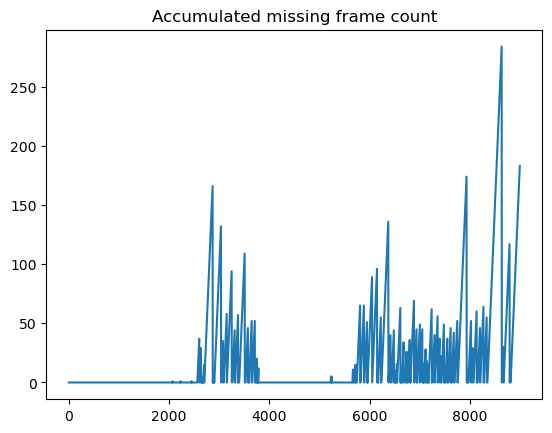

In [75]:
frame_cnt = missing_mask.shape[0]
acc_missing_mask = np.zeros((frame_cnt,))
for frame_idx in range(1, frame_cnt):
    if missing_mask[frame_idx] == 0:
        acc_missing_mask[frame_idx] = 0
    else:
        acc_missing_mask[frame_idx] = acc_missing_mask[frame_idx-1] + 1
plt.plot(acc_missing_mask)
plt.title('Accumulated missing frame count')
plt.show()


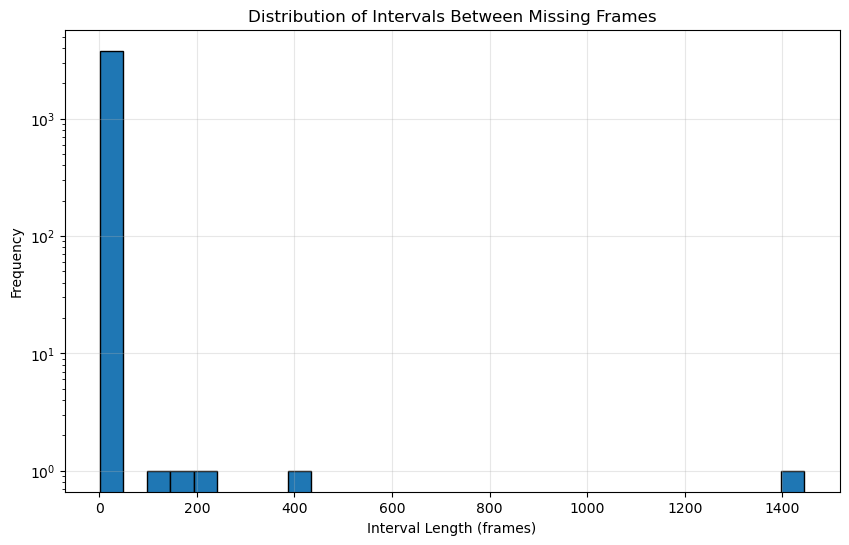

Mean interval: 1.82
Median interval: 1.00
Min interval: 1
Max interval: 1445


In [73]:
# Get indices where mask is 1
one_indices = np.where(missing_mask == 1)[0]

# Calculate intervals between consecutive 1's
intervals = one_indices[1:] - one_indices[:-1]

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(intervals, bins=30, edgecolor='black')
plt.xlabel('Interval Length (frames)')
plt.ylabel('Frequency')
plt.title('Distribution of Intervals Between Missing Frames')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# Print some statistics
print(f"Mean interval: {np.mean(intervals):.2f}")
print(f"Median interval: {np.median(intervals):.2f}")
print(f"Min interval: {np.min(intervals)}")
print(f"Max interval: {np.max(intervals)}")

In [72]:
tracked_pts_windows_reodered = reorder_by_polygon(tracked_pts_windows, missing_mask)
tracked_pts_windows_reodered.shape

 30%|██▉       | 2665/9000 [00:05<00:13, 481.38it/s]

window around frame2580 has no valid points
window around frame2581 has no valid points
window around frame2582 has no valid points
window around frame2583 has no valid points
window around frame2584 has no valid points
window around frame2585 has no valid points
window around frame2586 has no valid points
window around frame2587 has no valid points


 31%|███       | 2767/9000 [00:05<00:12, 495.13it/s]

window around frame2718 has no valid points
window around frame2719 has no valid points
window around frame2720 has no valid points
window around frame2721 has no valid points
window around frame2722 has no valid points
window around frame2723 has no valid points
window around frame2724 has no valid points
window around frame2725 has no valid points
window around frame2726 has no valid points
window around frame2727 has no valid points
window around frame2728 has no valid points
window around frame2729 has no valid points
window around frame2730 has no valid points
window around frame2731 has no valid points
window around frame2732 has no valid points
window around frame2733 has no valid points
window around frame2734 has no valid points
window around frame2735 has no valid points
window around frame2736 has no valid points
window around frame2737 has no valid points
window around frame2738 has no valid points
window around frame2739 has no valid points
window around frame2740 has no v

 32%|███▏      | 2864/9000 [00:05<00:14, 420.75it/s]

...

 99%|█████████▉| 8922/9000 [00:18<00:00, 403.05it/s]

window around frame8857 has no valid points
window around frame8858 has no valid points
window around frame8859 has no valid points
window around frame8860 has no valid points
window around frame8861 has no valid points
window around frame8862 has no valid points
window around frame8863 has no valid points
window around frame8864 has no valid points
window around frame8865 has no valid points
window around frame8866 has no valid points
window around frame8867 has no valid points
window around frame8868 has no valid points
window around frame8869 has no valid points
window around frame8870 has no valid points
window around frame8871 has no valid points
window around frame8872 has no valid points
window around frame8873 has no valid points
window around frame8874 has no valid points
window around frame8875 has no valid points
window around frame8876 has no valid points
window around frame8877 has no valid points
window around frame8878 has no valid points
window around frame8879 has no v

100%|██████████| 9000/9000 [00:19<00:00, 469.62it/s]

window around frame8936 has no valid points
window around frame8937 has no valid points
window around frame8938 has no valid points
window around frame8939 has no valid points
window around frame8940 has no valid points
window around frame8941 has no valid points
window around frame8942 has no valid points
window around frame8943 has no valid points
window around frame8944 has no valid points
window around frame8945 has no valid points
window around frame8946 has no valid points
window around frame8947 has no valid points
window around frame8948 has no valid points
window around frame8949 has no valid points
window around frame8950 has no valid points
window around frame8951 has no valid points
window around frame8952 has no valid points
window around frame8953 has no valid points
window around frame8954 has no valid points
window around frame8955 has no valid points
window around frame8956 has no valid points
window around frame8957 has no valid points
window around frame8958 has no v

(9000, 30, 17, 2)

## data augmentation per window

In [18]:
def get_dropout_mask(frame_cnt, window_size, pt_cnt, dropout_rate=0.01):
    mask = np.zeros((frame_cnt, pt_cnt))
    total_elements = frame_cnt * pt_cnt
    num_ones = int(total_elements * dropout_rate)
    indices = np.random.choice(total_elements, num_ones, replace=False)
    rows = indices // pt_cnt
    cols = indices % pt_cnt
    mask[rows, cols] = 1
    mask = np.tile(mask[:, np.newaxis, :], (1, window_size, 1))
    return mask

def augment_points(coords, dropout_rate=0.01, swap_rate=0.005):
    frame_cnt, window_size, pt_cnt = coords.shape[:3]
    
    # 1. dropout
    dropout_mask = get_dropout_mask(frame_cnt, window_size, pt_cnt, dropout_rate)
    # coords[dropout_mask == 1] = np.nan
    coords[dropout_mask == 1] = 0
    
    # 2. swap
    swap_frames = np.random.choice(frame_cnt, int(frame_cnt * swap_rate), replace=False)
    for frame_idx in swap_frames:
        swap_pts = np.random.choice(pt_cnt, np.random.randint(2, 5), replace=False)
        swap_pts_shuffled = np.random.permutation(swap_pts)
        coords[frame_idx, :, swap_pts] = coords[frame_idx, :, swap_pts_shuffled]
        
    return coords

In [20]:
test_mask = get_dropout_mask(10, 30, 17, 0.1)
first_mask = test_mask[:, 0, :]
for frame_idx in range(30):
    assert np.all(first_mask == test_mask[:, frame_idx, :])

In [48]:
tracked_pts_windows_reodered_augmented = augment_points(tracked_pts_windows_reodered, 0.01, 0.01)
tracked_pts_windows_reodered_augmented.shape

(9000, 30, 17, 2)

## all

In [ ]:
def load_data(
    raw_points_path=raw_points_path, 
    corrected_points_path=corrected_points_path, 
    video_path=video_path, 
    load_video=False,
    window_size=30,
    load_as_tensor=False,
    flatten=False,
    shuffle=True,
    augment=False, 
    dropout_rate=0.01,
    swap_rate=0.01, 
    split_size=0.9,
    ):
    _, coords_corrected = load_points(raw_points_path=raw_points_path, 
                                               corrected_points_path=corrected_points_path)

    # 1. get window
    coords_window = get_windows_wrapper([coords_corrected], window_size=window_size, flatten=flatten)[0]
    X = coords_window # for prediction
    
    # 2. reorder by polygon
    missing_mask = get_missing_mask(coords_corrected)
    coords_window = reorder_by_polygon(coords_window, missing_mask)
    
    # 3. augment
    if augment:
        coords_window_augmented = augment_points(coords_window, dropout_rate, swap_rate)
    else:
        coords_window_augmented = coords_window
        
    # 4. shuffle among windows 
    frame_indices = np.arange(len(coords_window_augmented))
    if shuffle:
        np.random.shuffle(frame_indices)
    coords_window_augmented = coords_window_augmented[frame_indices]
    coords_corrected = coords_corrected[frame_indices]
    
    # 5. train val split
    X_train, X_val, y_train, y_val = split_train_val(coords_window_augmented, coords_corrected, 
                                                     train_size=split_size)
    
    if load_video:
        video = video_loader(video_path=video_path, target_size=None, load_as_tensor=load_as_tensor)
        video_windows = get_sliding_windows(video, window_size=window_size)
        video_original = video_windows
        video_windows = video_windows[indices]
        video_train, video_val = split_train_val(video_windows, train_size=split_size)
        X_train = [video_train, X_train]
        X_val = [video_val, X_val]
        X = [video_original, X]
        
    return X_train, X_val, y_train, y_val, X